In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
train_dir = '/content/drive/MyDrive/dataset/train'
validation_dir = '/content/drive/MyDrive/dataset/test'

In [ ]:
num_classes = 21
image_size = (299,299)
batch_size = 32
learning_rate = 0.001
epochs = 10

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)


In [ ]:
valid_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1],3))

87910968/87910968 [==============================] - 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [ ]:
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
for layer in base_model.layers:
  layer.trainable = False


In [ ]:
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    validation_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1667 images belonging to 21 classes.
Found 420 images belonging to 21 classes.


In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.n // batch_size,
    epochs=epochs,
    validation_data=valid_generator,
    validation_steps=valid_generator.n // batch_size
)

Epoch 1/10
52/52 [==============================] - 774s 15s/step - loss: 0.6269 - accuracy: 0.8428 - val_loss: 0.2135 - val_accuracy: 0.9423
Epoch 2/10
52/52 [==============================] - 573s 11s/step - loss: 0.1974 - accuracy: 0.9511 - val_loss: 0.1512 - val_accuracy: 0.9471
Epoch 3/10
52/52 [==============================] - 570s 11s/step - loss: 0.1096 - accuracy: 0.9688 - val_loss: 0.1561 - val_accuracy: 0.9591
Epoch 4/10
52/52 [==============================] - 568s 11s/step - loss: 0.0763 - accuracy: 0.9804 - val_loss: 0.1703 - val_accuracy: 0.9567
Epoch 5/10
52/52 [==============================] - 571s 11s/step - loss: 0.0867 - accuracy: 0.9780 - val_loss: 0.1238 - val_accuracy: 0.9663
Epoch 6/10
52/52 [==============================] - 562s 11s/step - loss: 0.0676 - accuracy: 0.9804 - val_loss: 0.1399 - val_accuracy: 0.9639
Epoch 7/10
52/52 [==============================] - 561s 11s/step - loss: 0.0593 - accuracy: 0.9798 - val_loss: 0.1736 - val_accuracy: 0.9567
Epoch 

In [ ]:

model.save('/content/drive/MyDrive/models/model2.h5')


1/1 [==============================] - 2s 2s/step


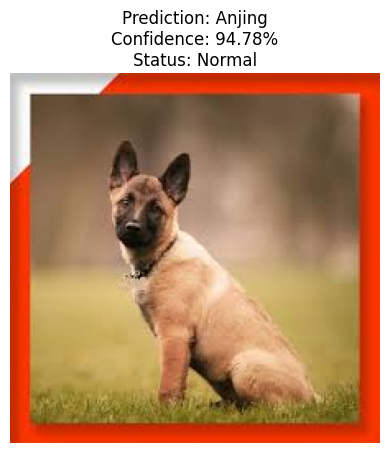

Anjing: 94.78%
Badak: 0.03%
Bekantan: 0.12%
Beruang Madu: 0.12%
Rangkong Badak: 0.01%
Cendrawasih: 0.09%
Domba: 0.81%
Elang Jawa: 0.11%
Gajah Asia: 0.00%
Kakaktua Putih: 0.04%
Kakaktua Raja: 0.10%
Kerbau: 0.21%
Kucing: 1.00%
Kuda: 0.23%
Kupu-kupu: 1.09%
Macan Tutul: 0.42%
Orang Utan: 0.30%
Singa: 0.32%
Tapir: 0.00%
Ular: 0.10%
Zebra: 0.09%
hello


In [ ]:
import PIL.Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


model = tf.keras.models.load_model('/content/drive/MyDrive/models/model2.h5')

class_labels = [
    "Anjing", "Badak", "Bekantan", "Beruang Madu", "Rangkong Badak",
    "Cendrawasih", "Domba", "Elang Jawa", "Gajah Asia", "Kakaktua Putih",
    "Kakaktua Raja", "Kerbau", "Kucing", "Kuda", "Kupu-kupu",
    "Macan Tutul", "Orang Utan", "Singa", "Tapir", "Ular", "Zebra"
]

conservation_status = {
    "Anjing": "Normal",
    "Badak": "Langka",
    "Bekantan": "Langka",
    "Beruang Madu": "Langka",
    "Rangkong Badak": "Langka",
    "Cendrawasih": "Langka",
    "Domba": "Normal",
    "Elang Jawa": "Langka",
    "Gajah Asia": "Langka",
    "Kakaktua Putih": "Langka",
    "Kakaktua Raja": "Langka",
    "Kerbau": "Normal",
    "Kucing": "Normal",
    "Kuda": "Normal",
    "Kupu-kupu": "Normal",
    "Macan Tutul": "Langka",
    "Orang Utan": "Langka",
    "Singa": "Normal",
    "Tapir": "Langka",
    "Ular": "Normal",
    "Zebra": "Normal"
}


def preprocess_image(image_path):
    img = PIL.Image.open(image_path)
    img = img.resize((299, 299))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    return img

def predict_animal(image_path):
    processed_image = preprocess_image(image_path)
    predictions = model.predict(processed_image)
    return predictions[0]


uploaded_file_path = 'test20.jpeg'
predictions = predict_animal(uploaded_file_path)

predicted_index = np.argmax(predictions)
predicted_label = class_labels[predicted_index]
confidence = predictions[predicted_index]

status = conservation_status[predicted_label]


img = PIL.Image.open(uploaded_file_path)
plt.imshow(img)
plt.axis('off')
plt.title(f'Prediction: {predicted_label}\nConfidence: {confidence:.2%}\nStatus: {status}')
plt.show()


percentages = predictions * 100
for label, percentage in zip(class_labels, percentages):
    print(f'{label}: {percentage:.2f}%')

